# Active Learning

> **Key idea**: Instead of labelling all available data, let the model choose which examples are most informative to label next.

Labelling data is expensive (domain experts, time, cost). Active learning uses the model's own uncertainty to select the most valuable samples for human annotation — typically reducing labelling effort by 70-90% for the same accuracy.

**The Active Learning Loop:**
```
Start with small labelled pool L
Train model on L
↓
Score all unlabelled examples in U with a query strategy
↓
Select top-k most informative → Oracle labels them
↓
Move labelled examples from U → L
↓
Retrain → repeat
```

---
## Query Strategies

| Strategy | Formula | Intuition |
|----------|---------|----------|
| **Confidence sampling** | $1 - \max_k P(y=k\|x)$ | Query the sample the model is least confident about |
| **Margin sampling** | $P(y_1^*\|x) - P(y_2^*\|x)$ | Query when top-2 class probabilities are closest |
| **Entropy sampling** | $-\sum_k P(y=k\|x) \log P(y=k\|x)$ | Query maximum entropy in the predictive distribution |
| **QBC (disagreement)** | Variance across committee predictions | Query where an ensemble disagrees most |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import entropy as scipy_entropy

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Libraries loaded')

Libraries loaded


---
## 1. Query Strategy Implementations

In [2]:
def confidence_sampling(model, X_pool, n_query):
    """Query samples where max class probability is lowest."""
    proba = model.predict_proba(X_pool)
    confidence = np.max(proba, axis=1)
    # Argsort ascending — least confident first
    query_idx = np.argsort(confidence)[:n_query]
    return query_idx, confidence


def margin_sampling(model, X_pool, n_query):
    """Query samples where top-2 class probabilities are closest."""
    proba = model.predict_proba(X_pool)
    # Sort descending, take top-2
    sorted_proba = np.sort(proba, axis=1)[:, ::-1]
    margin = sorted_proba[:, 0] - sorted_proba[:, 1]
    query_idx = np.argsort(margin)[:n_query]  # smallest margin = most uncertain
    return query_idx, margin


def entropy_sampling(model, X_pool, n_query):
    """Query samples with highest predictive entropy."""
    proba = model.predict_proba(X_pool)
    # Clip for numerical stability
    proba = np.clip(proba, 1e-10, 1.0)
    entropies = scipy_entropy(proba.T)
    query_idx = np.argsort(-entropies)[:n_query]  # highest entropy first
    return query_idx, entropies


def random_sampling(X_pool, n_query):
    """Random baseline — no model needed."""
    query_idx = np.random.choice(len(X_pool), n_query, replace=False)
    return query_idx


print('Query strategies defined')

Query strategies defined


---
## 2. Active Learning Loop

In [3]:
def active_learning_loop(X_train, y_train, X_test, y_test,
                          query_strategy='entropy',
                          initial_size=20, n_query=10, n_rounds=20):
    """
    Run the active learning loop.
    Returns accuracy at each round and total labels used.
    """
    N = len(X_train)
    # Start with a small random labelled set
    labelled_idx = np.random.choice(N, initial_size, replace=False)
    unlabelled_idx = np.setdiff1d(np.arange(N), labelled_idx)

    accuracies = []
    labels_used = [initial_size]

    for round_i in range(n_rounds):
        if len(unlabelled_idx) == 0:
            break

        X_L = X_train[labelled_idx]
        y_L = y_train[labelled_idx]

        model = LogisticRegression(max_iter=500, C=1.0)
        model.fit(X_L, y_L)

        acc = accuracy_score(y_test, model.predict(X_test))
        accuracies.append(acc)

        X_pool = X_train[unlabelled_idx]
        actual_query = min(n_query, len(unlabelled_idx))

        if query_strategy == 'entropy':
            local_idx, _ = entropy_sampling(model, X_pool, actual_query)
        elif query_strategy == 'margin':
            local_idx, _ = margin_sampling(model, X_pool, actual_query)
        elif query_strategy == 'confidence':
            local_idx, _ = confidence_sampling(model, X_pool, actual_query)
        else:  # random
            local_idx = random_sampling(X_pool, actual_query)

        # Map local pool indices back to global train indices
        global_idx = unlabelled_idx[local_idx]
        labelled_idx = np.concatenate([labelled_idx, global_idx])
        unlabelled_idx = np.setdiff1d(unlabelled_idx, global_idx)
        labels_used.append(len(labelled_idx))

    return accuracies, labels_used[:-1]


# Digits dataset
digits = load_digits()
X, y = digits.data, digits.target
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

strategies = ['entropy', 'margin', 'confidence', 'random']
colors = ['steelblue', 'darkorange', 'green', 'red']
results = {}

for strat in strategies:
    np.random.seed(42)
    accs, labels = active_learning_loop(
        X_train, y_train, X_test, y_test,
        query_strategy=strat, initial_size=20, n_query=15, n_rounds=25
    )
    results[strat] = (accs, labels)
    print(f'{strat:12s}: final acc={accs[-1]:.3f} with {labels[-1]} labels')

entropy     : final acc=0.970 with 380 labels


margin      : final acc=0.970 with 380 labels


confidence  : final acc=0.970 with 380 labels


random      : final acc=0.946 with 380 labels


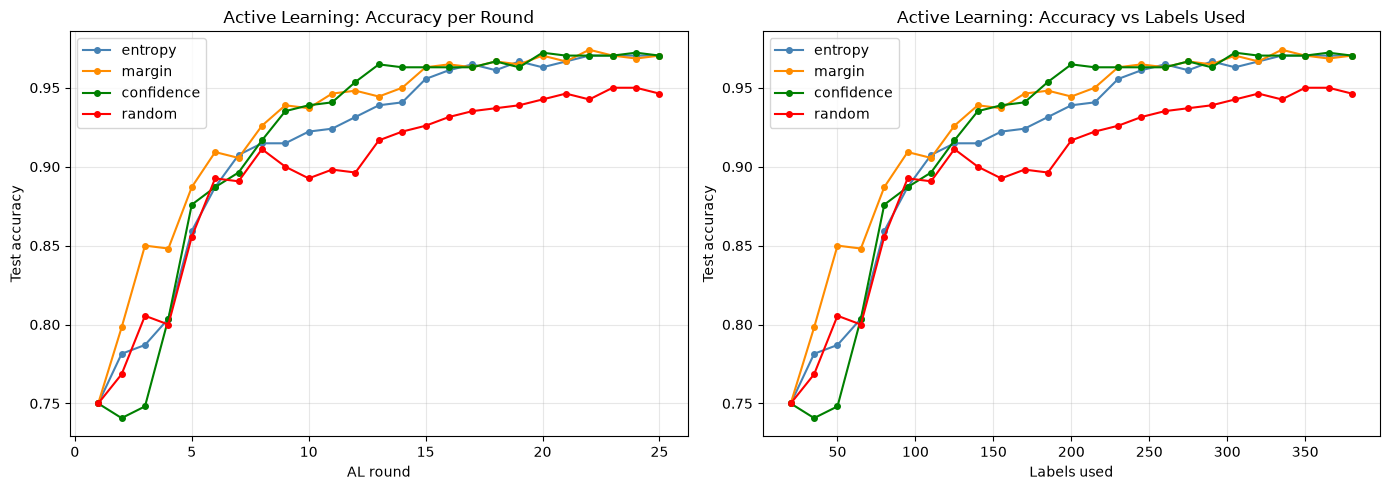

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (strat, (accs, labels)), color in zip(results.items(), colors):
    axes[0].plot(np.arange(1, len(accs)+1), accs, label=strat, color=color, marker='o', ms=4)
    axes[1].plot(labels, accs, label=strat, color=color, marker='o', ms=4)

axes[0].set_xlabel('AL round')
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Active Learning: Accuracy per Round')
axes[0].legend()

axes[1].set_xlabel('Labels used')
axes[1].set_ylabel('Test accuracy')
axes[1].set_title('Active Learning: Accuracy vs Labels Used')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Visualising Uncertainty Scores

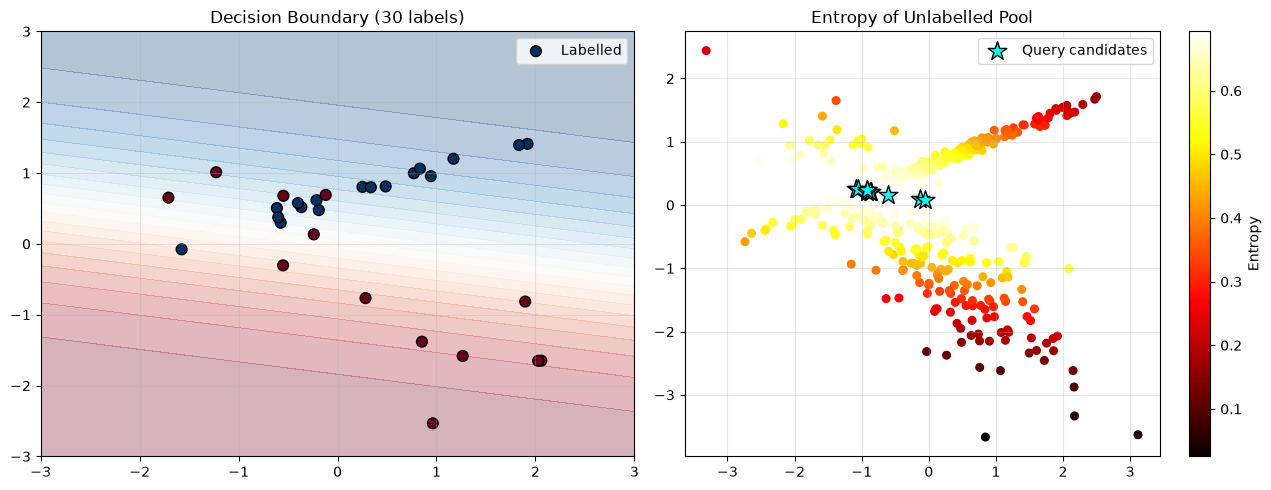

In [5]:
# 2D synthetic dataset for visualisation
X2d, y2d = make_classification(n_samples=500, n_features=2, n_redundant=0,
                                n_informative=2, n_clusters_per_class=1,
                                class_sep=0.8, random_state=42)
scaler2d = StandardScaler()
X2d = scaler2d.fit_transform(X2d)

# Train on 30 random points
init_idx = np.random.choice(500, 30, replace=False)
pool_idx = np.setdiff1d(np.arange(500), init_idx)

clf2d = LogisticRegression()
clf2d.fit(X2d[init_idx], y2d[init_idx])

# Get entropy for pool
proba2d = clf2d.predict_proba(X2d[pool_idx])
proba2d = np.clip(proba2d, 1e-10, 1.0)
entropy2d = scipy_entropy(proba2d.T)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: decision boundary + labelled points
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
Z = clf2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=20)
axes[0].scatter(X2d[init_idx, 0], X2d[init_idx, 1], c=y2d[init_idx],
                cmap='RdBu', edgecolors='k', s=60, label='Labelled')
axes[0].set_title('Decision Boundary (30 labels)')
axes[0].legend()

# Right: entropy map on unlabelled pool
sc = axes[1].scatter(X2d[pool_idx, 0], X2d[pool_idx, 1],
                      c=entropy2d, cmap='hot', s=30)
plt.colorbar(sc, ax=axes[1], label='Entropy')
# Highlight top-10 query candidates
top10 = pool_idx[np.argsort(-entropy2d)[:10]]
axes[1].scatter(X2d[top10, 0], X2d[top10, 1], marker='*', s=200,
                color='cyan', edgecolors='black', label='Query candidates', zorder=5)
axes[1].set_title('Entropy of Unlabelled Pool')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4. Query by Committee (QBC)

Train a **committee** of diverse models. Query samples where the committee **disagrees** the most.

**Vote entropy** as disagreement measure:
$$D(x) = -\sum_k \frac{V(y=k)}{|C|} \log \frac{V(y=k)}{|C|}$$
where $V(y=k)$ is the number of committee members predicting class $k$, and $|C|$ is committee size.

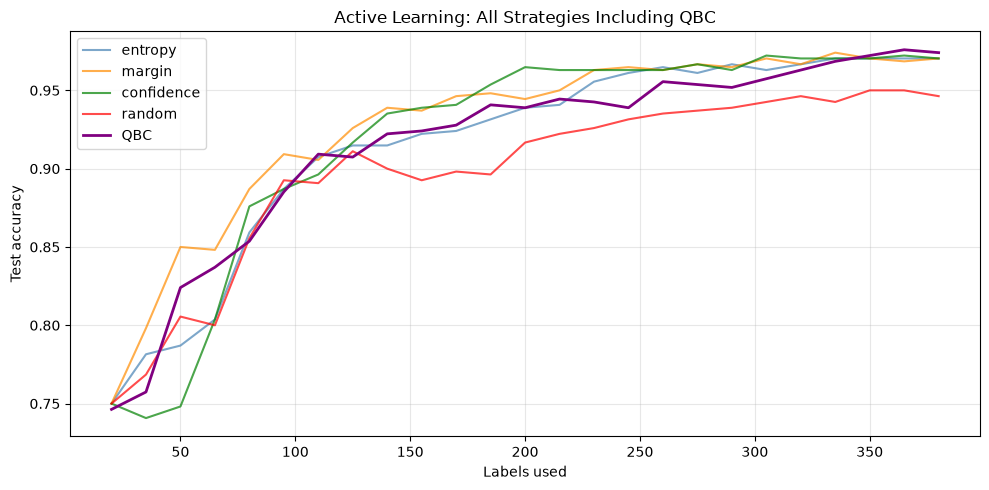

QBC final acc: 0.974 with 380 labels


In [6]:
def qbc_disagreement(committee, X_pool, n_query):
    """Vote entropy across committee predictions."""
    n_classes = len(set(committee[0].classes_))
    vote_counts = np.zeros((len(X_pool), n_classes))
    for clf in committee:
        preds = clf.predict(X_pool)
        for i, p in enumerate(preds):
            vote_counts[i, p] += 1
    vote_fractions = vote_counts / len(committee)
    # Entropy of vote distribution
    eps = 1e-10
    vote_fractions = np.clip(vote_fractions, eps, 1.0)
    disagreement = -np.sum(vote_fractions * np.log(vote_fractions), axis=1)
    query_idx = np.argsort(-disagreement)[:n_query]
    return query_idx, disagreement


def qbc_active_learning(X_train, y_train, X_test, y_test,
                          initial_size=20, n_query=15, n_rounds=25):
    N = len(X_train)
    labelled_idx = np.random.choice(N, initial_size, replace=False)
    unlabelled_idx = np.setdiff1d(np.arange(N), labelled_idx)

    accuracies = []
    labels_used = []

    for _ in range(n_rounds):
        if len(unlabelled_idx) < n_query:
            break

        X_L, y_L = X_train[labelled_idx], y_train[labelled_idx]

        # Diverse committee
        committee = [
            LogisticRegression(max_iter=300, C=0.5).fit(X_L, y_L),
            RandomForestClassifier(n_estimators=20, max_depth=5, random_state=1).fit(X_L, y_L),
            ExtraTreesClassifier(n_estimators=20, max_depth=5, random_state=2).fit(X_L, y_L),
        ]

        # Evaluate on test set (use first committee member as representative)
        acc = accuracy_score(y_test, committee[0].predict(X_test))
        accuracies.append(acc)
        labels_used.append(len(labelled_idx))

        X_pool = X_train[unlabelled_idx]
        local_idx, _ = qbc_disagreement(committee, X_pool, n_query)
        global_idx = unlabelled_idx[local_idx]
        labelled_idx = np.concatenate([labelled_idx, global_idx])
        unlabelled_idx = np.setdiff1d(unlabelled_idx, global_idx)

    return accuracies, labels_used


np.random.seed(42)
qbc_accs, qbc_labels = qbc_active_learning(X_train, y_train, X_test, y_test)

plt.figure()
for (strat, (accs, labels)), color in zip(results.items(), colors):
    plt.plot(labels, accs, label=strat, color=color, alpha=0.7)
plt.plot(qbc_labels, qbc_accs, label='QBC', color='purple', lw=2)
plt.xlabel('Labels used')
plt.ylabel('Test accuracy')
plt.title('Active Learning: All Strategies Including QBC')
plt.legend()
plt.tight_layout()
plt.show()

print(f'QBC final acc: {qbc_accs[-1]:.3f} with {qbc_labels[-1]} labels')

---
## 5. Label Efficiency Analysis

**Label efficiency** = labels needed to reach a target accuracy. Lower is better.

In [7]:
target_acc = 0.88

print(f'Labels needed to reach {target_acc:.0%} accuracy:')
print(f"{'Strategy':<15} {'Labels':<10} {'Reduction vs random'}")
print('-' * 45)

random_labels_needed = None
for strat in strategies:
    accs, labels = results[strat]
    idx = next((i for i, a in enumerate(accs) if a >= target_acc), None)
    if idx is not None:
        n_labels = labels[idx]
        if strat == 'random':
            random_labels_needed = n_labels
            reduction = '-'
        else:
            if random_labels_needed:
                reduction = f'{(1 - n_labels/random_labels_needed)*100:.1f}% fewer'
            else:
                reduction = 'N/A'
        print(f'{strat:<15} {n_labels:<10} {reduction}')
    else:
        print(f'{strat:<15} Not reached')

# Also check QBC
idx = next((i for i, a in enumerate(qbc_accs) if a >= target_acc), None)
if idx is not None:
    n_labels = qbc_labels[idx]
    if random_labels_needed:
        reduction = f'{(1 - n_labels/random_labels_needed)*100:.1f}% fewer'
    print(f'{"QBC":<15} {n_labels:<10} {reduction}')

Labels needed to reach 88% accuracy:
Strategy        Labels     Reduction vs random
---------------------------------------------
entropy         95         N/A
margin          80         N/A
confidence      95         N/A
random          95         -
QBC             95         0.0% fewer


---
## 6. Real-World Considerations

### Cold Start Problem
The first few labels must be chosen randomly — you can't use uncertainty without a model. A common heuristic is **cluster-based initialisation**: sample from $k$-means cluster centers to cover input space diversity.

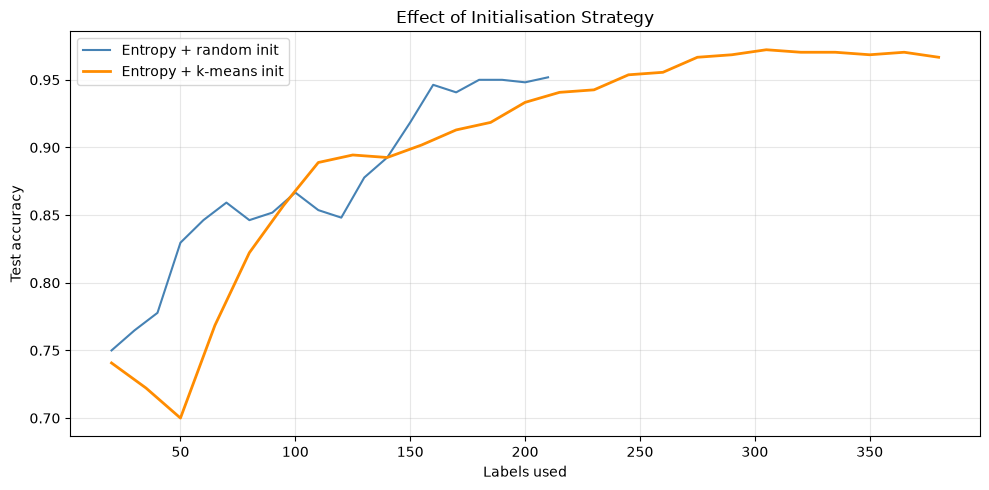

In [8]:
from sklearn.cluster import KMeans

def kmeans_init(X, n_init_labels):
    """Pick initial labels as closest samples to cluster centers."""
    km = KMeans(n_clusters=n_init_labels, random_state=42, n_init=5)
    km.fit(X)
    centers = km.cluster_centers_
    selected = []
    for center in centers:
        dists = np.linalg.norm(X - center, axis=1)
        selected.append(np.argmin(dists))
    return np.array(selected)


def al_loop_with_custom_init(X_train, y_train, X_test, y_test, init_fn,
                               initial_size=20, n_query=15, n_rounds=25):
    labelled_idx = init_fn(X_train, initial_size)
    unlabelled_idx = np.setdiff1d(np.arange(len(X_train)), labelled_idx)
    accuracies, labels_used = [], []

    for _ in range(n_rounds):
        if len(unlabelled_idx) < n_query:
            break
        model = LogisticRegression(max_iter=500)
        model.fit(X_train[labelled_idx], y_train[labelled_idx])
        acc = accuracy_score(y_test, model.predict(X_test))
        accuracies.append(acc)
        labels_used.append(len(labelled_idx))

        local_idx, _ = entropy_sampling(model, X_train[unlabelled_idx], n_query)
        global_idx = unlabelled_idx[local_idx]
        labelled_idx = np.concatenate([labelled_idx, global_idx])
        unlabelled_idx = np.setdiff1d(unlabelled_idx, global_idx)

    return accuracies, labels_used


np.random.seed(42)
# Entropy + random init
ent_rand_accs, ent_rand_labels = active_learning_loop(
    X_train, y_train, X_test, y_test, 'entropy')

# Entropy + k-means init
ent_km_accs, ent_km_labels = al_loop_with_custom_init(
    X_train, y_train, X_test, y_test,
    init_fn=kmeans_init
)

plt.figure()
plt.plot(ent_rand_labels, ent_rand_accs, label='Entropy + random init', color='steelblue')
plt.plot(ent_km_labels, ent_km_accs, label='Entropy + k-means init', color='darkorange', lw=2)
plt.xlabel('Labels used')
plt.ylabel('Test accuracy')
plt.title('Effect of Initialisation Strategy')
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Batch Active Learning

In practice, oracles (humans) label in **batches** — you send them 10-50 examples at once. Naively selecting the top-$k$ most uncertain samples often results in highly redundant queries (all near the same decision boundary).

**Core-Set** approach: select diverse samples that maximise coverage of unlabelled space.

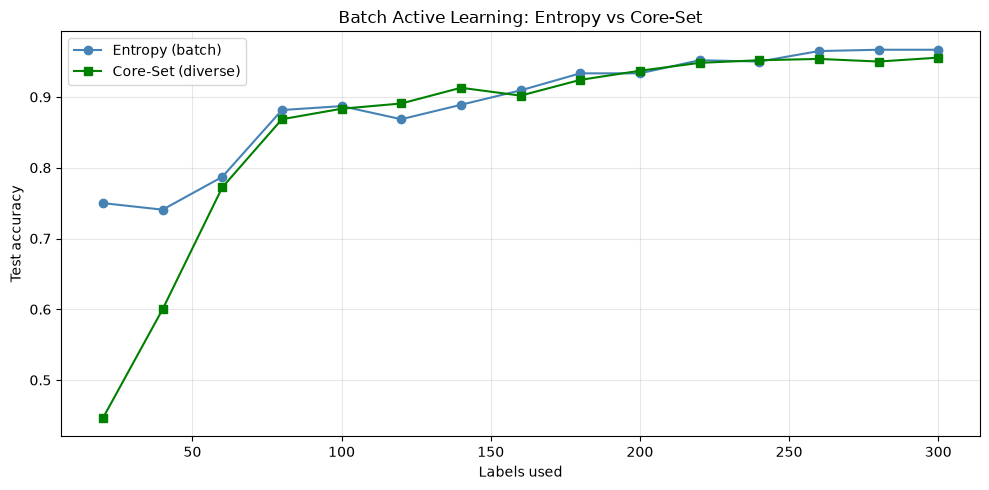

In [9]:
def coreset_greedy(X_pool, X_labelled, n_query):
    """
    Greedy core-set: iteratively pick the unlabelled point
    farthest from all already-selected (or labelled) points.
    """
    selected = []
    X_covered = X_labelled.copy()

    for _ in range(n_query):
        # Compute min distance from each pool point to any covered point
        min_dists = np.full(len(X_pool), np.inf)
        for xc in X_covered:
            dists = np.linalg.norm(X_pool - xc, axis=1)
            min_dists = np.minimum(min_dists, dists)

        # Pick the farthest
        best = np.argmax(min_dists)
        selected.append(best)
        X_covered = np.vstack([X_covered, X_pool[best]])

    return np.array(selected)


def batch_al_loop(X_train, y_train, X_test, y_test, strategy='entropy',
                   initial_size=20, batch_size=20, n_rounds=15):
    N = len(X_train)
    labelled_idx = np.random.choice(N, initial_size, replace=False)
    unlabelled_idx = np.setdiff1d(np.arange(N), labelled_idx)
    accuracies, labels_used = [], []

    for _ in range(n_rounds):
        if len(unlabelled_idx) < batch_size:
            break
        model = LogisticRegression(max_iter=500)
        model.fit(X_train[labelled_idx], y_train[labelled_idx])
        acc = accuracy_score(y_test, model.predict(X_test))
        accuracies.append(acc)
        labels_used.append(len(labelled_idx))

        X_pool = X_train[unlabelled_idx]
        if strategy == 'coreset':
            local_idx = coreset_greedy(X_pool, X_train[labelled_idx], batch_size)
        else:
            local_idx, _ = entropy_sampling(model, X_pool, batch_size)

        global_idx = unlabelled_idx[local_idx]
        labelled_idx = np.concatenate([labelled_idx, global_idx])
        unlabelled_idx = np.setdiff1d(unlabelled_idx, global_idx)

    return accuracies, labels_used


np.random.seed(42)
entropy_batch_accs, entropy_batch_labels = batch_al_loop(
    X_train, y_train, X_test, y_test, 'entropy', batch_size=20)
coreset_accs, coreset_labels = batch_al_loop(
    X_train, y_train, X_test, y_test, 'coreset', batch_size=20)

plt.figure()
plt.plot(entropy_batch_labels, entropy_batch_accs, label='Entropy (batch)', color='steelblue', marker='o')
plt.plot(coreset_labels, coreset_accs, label='Core-Set (diverse)', color='green', marker='s')
plt.xlabel('Labels used')
plt.ylabel('Test accuracy')
plt.title('Batch Active Learning: Entropy vs Core-Set')
plt.legend()
plt.tight_layout()
plt.show()

---
## Summary

| Strategy | Type | Strength | Weakness |
|----------|------|----------|----------|
| **Confidence** | Uncertainty | Simple, fast | Only uses max probability |
| **Margin** | Uncertainty | Good for binary | Less informative for many classes |
| **Entropy** | Uncertainty | Full distribution, robust | Needs calibrated probabilities |
| **QBC** | Committee | Model-agnostic, ensemble diversity | 3-5× training cost |
| **Core-Set** | Diversity | Avoids redundancy in batches | Expensive distance computation |

**Key takeaways**:
1. Entropy sampling is the best default — uses full predictive distribution
2. For batch queries (≥10 samples per round), add a diversity component to avoid redundancy
3. K-means initialisation beats random cold start, especially with a small initial budget
4. Active learning gains diminish beyond ~50% of data — it's most valuable in the low-label regime

---
## Additional Learning Resources

- **Settles (2009)** — *Active Learning Literature Survey* — UW Technical Report 1648, the canonical overview
- **Ren et al. (2021)** — *A Survey of Deep Active Learning* — ACM Computing Surveys, modern deep learning perspective
- **Sener & Savarese (2018)** — *Active Learning for Convolutional Neural Networks: A Core-Set Approach* — ICLR 2018
- **Gal et al. (2017)** — *Deep Bayesian Active Learning with Image Data* — ICML 2017, BALD acquisition function
- **modAL Documentation** — https://modal-python.readthedocs.io/ — Python AL library built on scikit-learn
- **small-text** — https://github.com/webis-de/small-text — Scalable AL for text classification